
**Kaggle name**: 21715165

**Srijana Tamang**
Student ID: 21715165

COMP 6013 Explainable Approaches to Machine Learning

This notebook contains my solution to the COMP6013 assignment, which focuses on predicting the peak pressure resulting from Boiling Liquid Expanding Vapour Explosions.  BLEVEs are intense explosions caused by the fast expansion of liquid gases, which can produce potentially deadly blast waves.  The purpose of this assignment is to use different machine learning Models to estimate blast wave pressures around obstructions.

Firstly, importing
- **pandas**: For data manipulation and analysis
- **numpy**: For numerical computations and array operations  
- **matplotlib.pyplot**: For creating visualizations and plots

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **1. Loading Data**

In [72]:
#loading train and test data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# **2. Understanding Data**

In [73]:
#Display the first few rows of the training data
train_df.head()


,Unnamed: 0,Tank Failure Pressure (bar),Liquid Ratio,Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Status,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar)
0,3203.0,14.26,0.25,1.58,8.61,1.79,1.01,1.40,457.14,423.07,...,Superheated,37.9,-1.0,152.0,18.0,2.0,19.75,5.70,3.1,0.588298
1,3204.0,14.14,0.25,1.59,8.58,1.81,1.00,1.41,457.71,422.82,...,Superheated,37.9,-1.0,152.0,19.0,3.0,20.00,-5.15,-1.5,0.551524
2,3205.0,14.05,0.24,1.62,8.59,1.79,0.98,1.38,456.58,422.37,...,Superheated,37.9,-1.0,152.0,20.0,3.0,20.00,-5.15,0.8,0.550813
3,3206.0,14.17,0.24,1.59,8.60,1.80,0.98,1.40,456.81,423.28,...,Superheated,37.9,-1.0,152.0,21.0,3.0,20.00,-5.15,3.1,0.528906
4,3207.0,14.09,0.24,1.59,8.60,1.80,1.00,1.40,456.93,423.19,...,Superheated,37.9,-1.0,152.0,22.0,4.0,20.00,-4.90,3.4,0.454363


In [74]:
#Display the first few rows of the test data
test_df.head()

,Unnamed: 0,Tank Failure Pressure (bar),Liquid Ratio,Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Obstacle Angle,Status,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z
0,0,37.9,0.412227,0.8,6.6,0.4,0.8,0.2,317.6,337.5,...,0,Subcooled,42.5,-42,96.7,1,1,8.05,-4.3,-0.7
1,1,37.9,0.412227,0.8,6.6,0.4,0.8,0.2,317.6,337.5,...,0,Subcooled,42.5,-42,96.7,2,1,8.05,-4.3,5.1
2,2,37.9,0.412227,0.8,6.6,0.4,0.8,0.2,317.6,337.5,...,0,Subcooled,42.5,-42,96.7,3,1,8.05,-4.3,10.9
3,3,37.9,0.412227,0.8,6.6,0.4,0.8,0.2,317.6,337.5,...,0,Subcooled,42.5,-42,96.7,4,1,8.05,0.0,-0.7
4,4,37.9,0.412227,0.8,6.6,0.4,0.8,0.2,317.6,337.5,...,0,Subcooled,42.5,-42,96.7,5,1,8.05,0.0,5.1


In [75]:
#Information and description of train data
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       10043 non-null  float64
 1   Tank Failure Pressure (bar)      10040 non-null  float64
 2   Liquid Ratio                     10041 non-null  float64
 3   Tank Width (m)                   10043 non-null  float64
 4   Tank Length (m)                  10045 non-null  float64
 5   Tank Height (m)                  10042 non-null  float64
 6   BLEVE Height (m)                 10040 non-null  float64
 7   Vapour Height (m)                10041 non-null  float64
 8   Vapour Temperature (K)           10022 non-null  float64
 9   Liquid Temperature (K)           10022 non-null  float64
 10  Obstacle Distance to BLEVE (m)   10042 non-null  float64
 11  Obstacle Width (m)               10042 non-null  float64
 12  Obstacle Height (m

,Unnamed: 0,Tank Failure Pressure (bar),Liquid Ratio,Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Obstacle Angle,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar)
count,10043.000000,10040.000000,10041.000000,10043.000000,10045.000000,10042.000000,10040.000000,10041.000000,10022.000000,10022.000000,...,10042.000000,10022.000000,10023.000000,10021.000000,10042.000000,10040.000000,10043.000000,10041.000000,10043.000000,10044.000000
mean,8202.264363,37.983131,0.494445,1.726197,5.525386,1.641390,1.028982,0.855979,398.850036,343.708088,...,14.099781,40.012273,-19.837174,126.576679,14.007469,2.334960,12.945712,2.910915,3.105118,0.361770
std,2886.578512,233.864180,0.227213,0.763225,2.631281,0.728311,0.572448,0.537254,71.504617,36.609621,...,9.209574,2.292440,20.433469,27.561571,7.791977,1.334432,4.164641,4.638664,4.263664,0.505487
min,3203.000000,4.890000,0.100000,0.380000,0.580000,0.380000,-0.020000,0.180000,281.130000,282.540000,...,0.000000,37.900000,-42.000000,96.700000,1.000000,1.000000,5.150000,-9.050000,-2.900000,0.016098
25%,5703.500000,13.177500,0.280000,1.010000,3.210000,1.010000,0.590000,0.410000,341.940000,312.580000,...,6.000000,37.900000,-42.000000,96.700000,7.000000,1.000000,9.350000,-0.150000,-0.600000,0.102128
50%,8204.000000,21.375000,0.510000,1.790000,5.410000,1.600000,1.010000,0.780000,389.165000,342.320000,...,14.000000,37.900000,-1.000000,152.000000,14.000000,2.000000,12.750000,2.700000,2.300000,0.203185
75%,10701.500000,32.822500,0.680000,2.400000,7.820000,2.210000,1.590000,1.210000,445.000000,367.990000,...,21.000000,42.500000,-1.000000,152.000000,21.000000,3.000000,16.250000,6.150000,5.500000,0.413152
max,13202.000000,4882.573607,0.900000,3.020000,10.020000,3.020000,2.020000,2.620000,573.880000,425.120000,...,30.000000,42.500000,-1.000000,152.000000,27.000000,5.000000,23.750000,19.550000,16.000000,9.170477


In [76]:
#Information and description of test data
test_df.info()
test_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       3203 non-null   int64  
 1   Tank Failure Pressure (bar)      3203 non-null   float64
 2   Liquid Ratio                     3203 non-null   float64
 3   Tank Width (m)                   3203 non-null   float64
 4   Tank Length (m)                  3203 non-null   float64
 5   Tank Height (m)                  3203 non-null   float64
 6   BLEVE Height (m)                 3203 non-null   float64
 7   Vapour Height (m)                3203 non-null   float64
 8   Vapour Temperature (K)           3203 non-null   float64
 9   Liquid Temperature (K)           3203 non-null   float64
 10  Obstacle Distance to BLEVE (m)   3203 non-null   int64  
 11  Obstacle Width (m)               3203 non-null   int64  
 12  Obstacle Height (m) 

,Unnamed: 0,Tank Failure Pressure (bar),Liquid Ratio,Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Obstacle Thickness (m),Obstacle Angle,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z
count,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.00000,3203.000000,...,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000
mean,1601.000000,23.002185,0.517537,1.682610,5.361349,1.670184,1.025289,0.801499,396.38183,341.963846,...,1.632407,15.338745,40.381673,-23.119263,122.165969,13.973462,2.328754,12.888870,3.136341,3.288261
std,924.770782,9.909509,0.227546,0.744369,2.473801,0.778534,0.585135,0.524191,74.69558,33.639999,...,0.770594,9.091723,2.293172,20.439139,27.567912,7.786075,1.331971,4.320394,4.730995,4.319066
min,0.000000,5.400000,0.122616,0.400000,0.800000,0.400000,0.000000,0.200000,283.70000,285.600000,...,0.400000,0.000000,37.900000,-42.000000,96.700000,1.000000,1.000000,5.250000,-7.850000,-2.800000
25%,800.500000,13.800000,0.336426,1.000000,3.200000,1.000000,0.600000,0.400000,328.80000,314.600000,...,1.000000,7.000000,37.900000,-42.000000,96.700000,7.000000,1.000000,9.175000,0.000000,-0.500000
50%,1601.000000,23.800000,0.508093,1.600000,5.400000,1.600000,1.000000,0.600000,388.40000,340.000000,...,1.600000,15.000000,42.500000,-42.000000,96.700000,14.000000,2.000000,12.600000,3.100000,2.700000
75%,2401.500000,30.700000,0.721171,2.200000,7.400000,2.400000,1.600000,1.000000,435.10000,362.500000,...,2.400000,23.000000,42.500000,-1.000000,152.000000,21.000000,3.000000,16.550000,6.600000,5.700000
max,3202.000000,41.900000,0.881677,3.000000,10.000000,3.000000,2.000000,2.600000,571.80000,422.700000,...,3.000000,30.000000,42.500000,-1.000000,152.000000,27.000000,5.000000,22.750000,14.750000,16.700000


# 3 **. Cleaning Data**




**Finding Duplicates in training and testing data and removing duplicates**

In [77]:
# Finding duplicates within the training data
duplicate_rows_train = train_df.duplicated().sum()
print("Duplicated rows in train data :", duplicate_rows_train)
# Finding duplicates within the test data
duplicate_rows_test = test_df.duplicated().sum()
print("Duplicated rows in test data :", duplicate_rows_test)

Duplicated rows in train data : 50
Duplicated rows in test data : 0


In [78]:
#remove duplicate row
train_df = train_df.drop_duplicates()
print("Duplicate row has been removed")
#check duplicates
train_duplicates = train_df.duplicated().sum()
print("No. of duplicate row in train data: " ,train_duplicates)

Duplicate row has been removed
No. of duplicate row in train data:  0


In [79]:

# Drop 'Unnamed: 0'
for df_name, df in zip(['train_data', 'test_data'], [train_df, test_df]):
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
        print(f"Dropped 'Unnamed: 0' from {df_name}")

Dropped 'Unnamed: 0' from train_data
Dropped 'Unnamed: 0' from test_data


#  **4. Checking and Handling Missing Values**

This shows us which features have missing values and how many are missing.Only columns with at least one missing value will appear in the output.
We need to handle these missing values before model training.

In [80]:
## Check for missing values
missing_values = train_df.isnull().sum()
print("\nMissing values per column for train data:")
display(missing_values[missing_values > 0])



Missing values per column for train data:


,0
Tank Failure Pressure (bar),10
Liquid Ratio,9
Tank Width (m),7
Tank Length (m),5
Tank Height (m),8
BLEVE Height (m),10
Vapour Height (m),9
Vapour Temperature (K),28
Liquid Temperature (K),28
Obstacle Distance to BLEVE (m),8


In [81]:
# Check for missing values
missing_values = test_df.isnull().sum()
print("\nMissing values per column for test data:")
display(missing_values[missing_values > 0])


Missing values per column for test data:


,0


In [82]:
# Handle Missing Values
def handling_missing_data(df):
    df_copy = df.copy()
    numerical_cols = df_copy.select_dtypes(include=['float64', 'int64']).columns
    categorical_cols = df_copy.select_dtypes(include=['object']).columns

    # For numerical columns: try mean, median, or 0 based on distribution
    for col in numerical_cols:
        # Check skewness to decide what imputation method to use
        if df_copy[col].skew() > 1:  # Highly skewed
            df_copy[col] = df_copy[col].fillna(df_copy[col].median())
        else:  # Normal distribution
            df_copy[col] = df_copy[col].fillna(df_copy[col].mean())

    # For categorical columns, use mode
    for col in categorical_cols:
        df_copy[col] = df_copy[col].fillna(df_copy[col].mode()[0])

    return df_copy

train_df = handling_missing_data(train_df)

In [83]:
## Check for missing values
missing_values = train_df.isnull().sum()
print("\nMissing values per column for train data:")
display(missing_values[missing_values > 0])


Missing values per column for train data:


,0


# 5.Encoding

We need to convert categorical variables to numerical format because most machine learning algorithms cannot process text data directly.

*   Firstly, checking the data types of training and testing data.
*   Then,Examining the Distribution of 'Status' Feature.

*   After that, Standardizes the 'Status' variable to only two categories: 'Superheated' and 'Subcooled'
*   Validation of Categorical Standardization


*   Applying one-hot encoding for categorical variables.







In [84]:
# Display the data types of the training dataframe
print(train_df.dtypes)
print()
# Display the data types of the testing dataframe
print(test_df.dtypes)

Tank Failure Pressure (bar)        float64
Liquid Ratio                       float64
Tank Width (m)                     float64
Tank Length (m)                    float64
Tank Height (m)                    float64
BLEVE Height (m)                   float64
Vapour Height (m)                  float64
Vapour Temperature (K)             float64
Liquid Temperature (K)             float64
Obstacle Distance to BLEVE (m)     float64
Obstacle Width (m)                 float64
Obstacle Height (m)                float64
Obstacle Thickness (m)             float64
Obstacle Angle                     float64
Status                              object
Liquid Critical Pressure (bar)     float64
Liquid Boiling Temperature (K)     float64
Liquid Critical Temperature (K)    float64
Sensor ID                          float64
Sensor Position Side               float64
Sensor Position x                  float64
Sensor Position y                  float64
Sensor Position z                  float64
Target Pres

In [85]:
print("The value of train_df in 'Status' is:")
print(train_df["Status"].value_counts())
print()
print("The value of test_df in 'Status' is:")
print(test_df["Status"].value_counts())

The value of train_df in 'Status' is:
Status
Subcooled      6184
Superheated    3736
subcooled        23
Subcool          17
Subcoled         14
Saperheated      10
superheated       9
Superheat         7
Name: count, dtype: int64

The value of test_df in 'Status' is:
Status
Subcooled      1971
Superheated    1232
Name: count, dtype: int64


In [86]:
# Standardize status values to have two categories only: 'Superheated' and 'Subcooled'
train_df['Status'] = train_df['Status'].str.lower()
train_df['Status'] = train_df['Status'].replace({
    'superheat': 'superheated',
    'saperheated': 'superheated',
    'superheated': 'superheated',
    'subcool': 'subcooled',
    'subcoled': 'subcooled'
})

In [87]:
print("After cleaning, Status values:")
display(train_df['Status'].value_counts())

After cleaning, Status values:


,count
Status,
subcooled,6238
superheated,3762


In [88]:
test_df['Status'] = test_df['Status'].str.lower()

In [89]:
# Checking unique values in likely categorical columns
categorical_columns = ['Status']
unique_values = {column: train_df[column].unique() for column in categorical_columns}
unique_values

{'Status': array(['superheated', 'subcooled'], dtype=object)}

In [90]:
# Apply one-hot encoding (Train Data)
train_df = pd.get_dummies(train_df, columns=['Status'], drop_first=False)

# Apply one-hot encoding (Test Data)
test_df = pd.get_dummies(test_df, columns=['Status'], drop_first=False)

In [91]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Tank Failure Pressure (bar)      10000 non-null  float64
 1   Liquid Ratio                     10000 non-null  float64
 2   Tank Width (m)                   10000 non-null  float64
 3   Tank Length (m)                  10000 non-null  float64
 4   Tank Height (m)                  10000 non-null  float64
 5   BLEVE Height (m)                 10000 non-null  float64
 6   Vapour Height (m)                10000 non-null  float64
 7   Vapour Temperature (K)           10000 non-null  float64
 8   Liquid Temperature (K)           10000 non-null  float64
 9   Obstacle Distance to BLEVE (m)   10000 non-null  float64
 10  Obstacle Width (m)               10000 non-null  float64
 11  Obstacle Height (m)              10000 non-null  float64
 12  Obstacle Thickness (m)  

In [92]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Tank Failure Pressure (bar)      3203 non-null   float64
 1   Liquid Ratio                     3203 non-null   float64
 2   Tank Width (m)                   3203 non-null   float64
 3   Tank Length (m)                  3203 non-null   float64
 4   Tank Height (m)                  3203 non-null   float64
 5   BLEVE Height (m)                 3203 non-null   float64
 6   Vapour Height (m)                3203 non-null   float64
 7   Vapour Temperature (K)           3203 non-null   float64
 8   Liquid Temperature (K)           3203 non-null   float64
 9   Obstacle Distance to BLEVE (m)   3203 non-null   int64  
 10  Obstacle Width (m)               3203 non-null   int64  
 11  Obstacle Height (m)              3203 non-null   int64  
 12  Obstacle Thickness (

# 6.Feature Transformation
Log Transformation of Target Variable


*   Applies a log transformation to the target variable to address skewness
*   Visualizes both original and transformed distributions for comparison
*   Helps achieve a more normal distribution for regression modeling





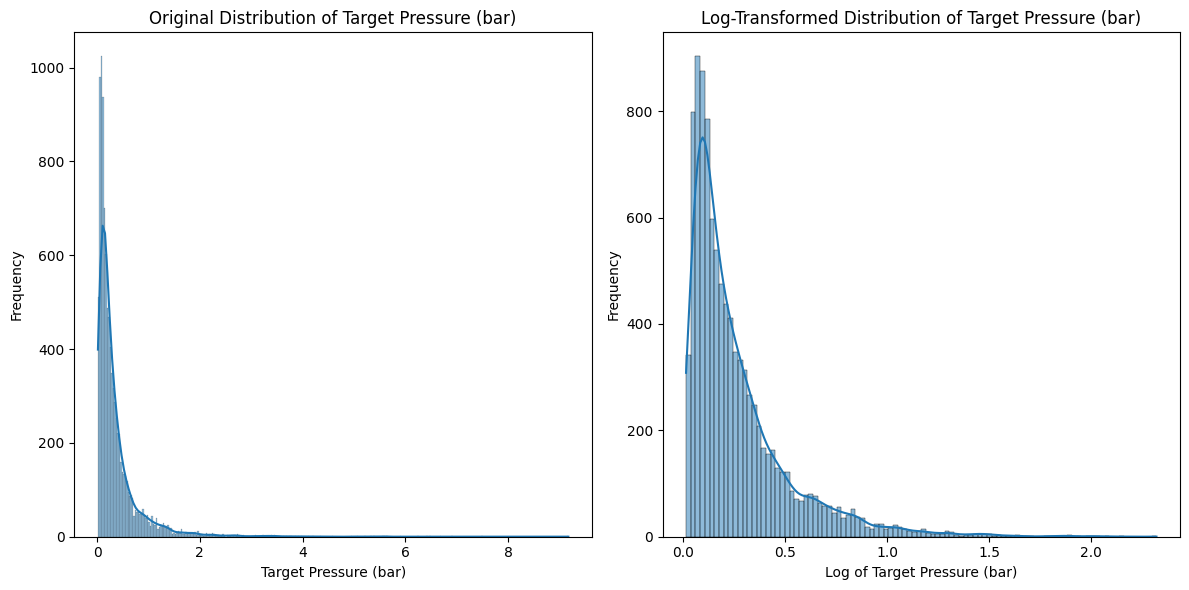

In [93]:
import seaborn as sns
#Taking Log on Target Pressure Bar
target_feature = train_df['Target Pressure (bar)'].copy()

# Apply log transformation to 'Target Pressure (bar)'
train_df['Target Pressure (bar)'] = np.log1p(train_df['Target Pressure (bar)'])

# Plotting both original and transformed distributions
plt.figure(figsize=(12, 6))

# Original 'Target Pressure (bar)'
plt.subplot(1, 2, 1)
sns.histplot(target_feature, kde=True)
plt.title('Original Distribution of Target Pressure (bar)')
plt.xlabel('Target Pressure (bar)')
plt.ylabel('Frequency')

# Log-Transformed 'Target Pressure (bar)'
plt.subplot(1, 2, 2)
sns.histplot(train_df['Target Pressure (bar)'], kde=True)
plt.title('Log-Transformed Distribution of Target Pressure (bar)')
plt.xlabel('Log of Target Pressure (bar)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 7.Outlier Detection and Handling


*   Identifying Outliers Using Z-Score Method
*   Removing Outliers from Training Data



In [94]:
from scipy import stats
# Finding Outliers
# Calculate Z-scores for all numerical columns in the training data
z_scores = np.abs(stats.zscore(train_df.select_dtypes(include=[np.number])))
outliers = (z_scores > 3)
# Create a DataFrame to visualize outliers for each column
outlier_counts = pd.DataFrame(outliers, columns=train_df.select_dtypes(include=[np.number]).columns).sum()
outlier_counts[outlier_counts > 0]

#removing outliers
from scipy.stats import zscore
# Separate features from target variable
train_features = train_df.drop('Target Pressure (bar)', axis=1)  # Define train_features

# Now calculate z-scores using train_features
z_scores = np.abs(zscore(train_features.select_dtypes(include=[np.number])))

# Create a mask for non-outlier rows (z-score < 3 for all columns)
clean_mask = (z_scores < 3).all(axis=1)

# Filter both features and target using the clean mask
X_clean = train_features[clean_mask]
y_clean = train_df.loc[clean_mask, 'Target Pressure (bar)']

print(f"Outliers removed successfully. Rows before: {len(train_df)}, after: {len(X_clean)}")

Outliers removed successfully. Rows before: 10000, after: 9897


# 8.Feature Engineering
Creating Derived Features to Improve Model Performance

In [95]:

# new features that are useful for the model
def feature_engineering(df):
    # Tank Dimension Ratios
    df['Tank Height to Width Ratio'] = df['Tank Height (m)'] / df['Tank Width (m)']
    df['Tank Length to Width Ratio'] = df['Tank Length (m)'] / df['Tank Width (m)']

    # Relative Positioning
    df['Relative Obstacle Distance'] = df['Obstacle Distance to BLEVE (m)'] / df['Tank Width (m)']
    df['Normalized Obstacle Distance'] = df['Obstacle Distance to BLEVE (m)'] / (df['Tank Width (m)'] + df['Tank Length (m)'])

    # Combined Temperature Features
    df['Temperature Difference'] = df['Vapour Temperature (K)'] - df['Liquid Temperature (K)']
    df['Average Temperature (K)'] = (df['Vapour Temperature (K)'] + df['Liquid Temperature (K)']) / 2

    # Scaled Pressure
    df['Scaled Tank Failure Pressure'] = df['Tank Failure Pressure (bar)'] / df['Liquid Critical Pressure (bar)']
    df['Pressure Differential (bar)'] = df['Tank Failure Pressure (bar)'] - df['Liquid Critical Pressure (bar)']

    # Tank Base and Surface Area
    df['Tank Base Area (m^2)'] = df['Tank Width (m)'] * df['Tank Length (m)']
    df['Tank Surface Area (m^2)'] = 2 * (
        df['Tank Width (m)'] * df['Tank Length (m)'] +
        df['Tank Height (m)'] * df['Tank Length (m)'] +
        df['Tank Height (m)'] * df['Tank Width (m)']
    )

    # Vapor-Liquid Relationship
    df['Vapour to Liquid Ratio'] = df['Vapour Height (m)'] / df['Tank Height (m)']

    # Obstacle Impact
    df['Obstacle Impact Factor'] = (df['Obstacle Width (m)'] * df['Obstacle Height (m)']) / df['Obstacle Distance to BLEVE (m)']

    # Volumes
    df['Tank Volume (m^3)'] = df['Tank Width (m)'] * df['Tank Length (m)'] * df['Tank Height (m)']
    df['Obstacle Volume (m^3)'] = df['Obstacle Width (m)'] * df['Obstacle Height (m)'] * df['Obstacle Thickness (m)']

    return df

train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)

In [96]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Tank Failure Pressure (bar)      10000 non-null  float64
 1   Liquid Ratio                     10000 non-null  float64
 2   Tank Width (m)                   10000 non-null  float64
 3   Tank Length (m)                  10000 non-null  float64
 4   Tank Height (m)                  10000 non-null  float64
 5   BLEVE Height (m)                 10000 non-null  float64
 6   Vapour Height (m)                10000 non-null  float64
 7   Vapour Temperature (K)           10000 non-null  float64
 8   Liquid Temperature (K)           10000 non-null  float64
 9   Obstacle Distance to BLEVE (m)   10000 non-null  float64
 10  Obstacle Width (m)               10000 non-null  float64
 11  Obstacle Height (m)              10000 non-null  float64
 12  Obstacle Thickness (m)  

In [97]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Tank Failure Pressure (bar)      3203 non-null   float64
 1   Liquid Ratio                     3203 non-null   float64
 2   Tank Width (m)                   3203 non-null   float64
 3   Tank Length (m)                  3203 non-null   float64
 4   Tank Height (m)                  3203 non-null   float64
 5   BLEVE Height (m)                 3203 non-null   float64
 6   Vapour Height (m)                3203 non-null   float64
 7   Vapour Temperature (K)           3203 non-null   float64
 8   Liquid Temperature (K)           3203 non-null   float64
 9   Obstacle Distance to BLEVE (m)   3203 non-null   int64  
 10  Obstacle Width (m)               3203 non-null   int64  
 11  Obstacle Height (m)              3203 non-null   int64  
 12  Obstacle Thickness (

# 9.Correlation Analysis with Target Variable

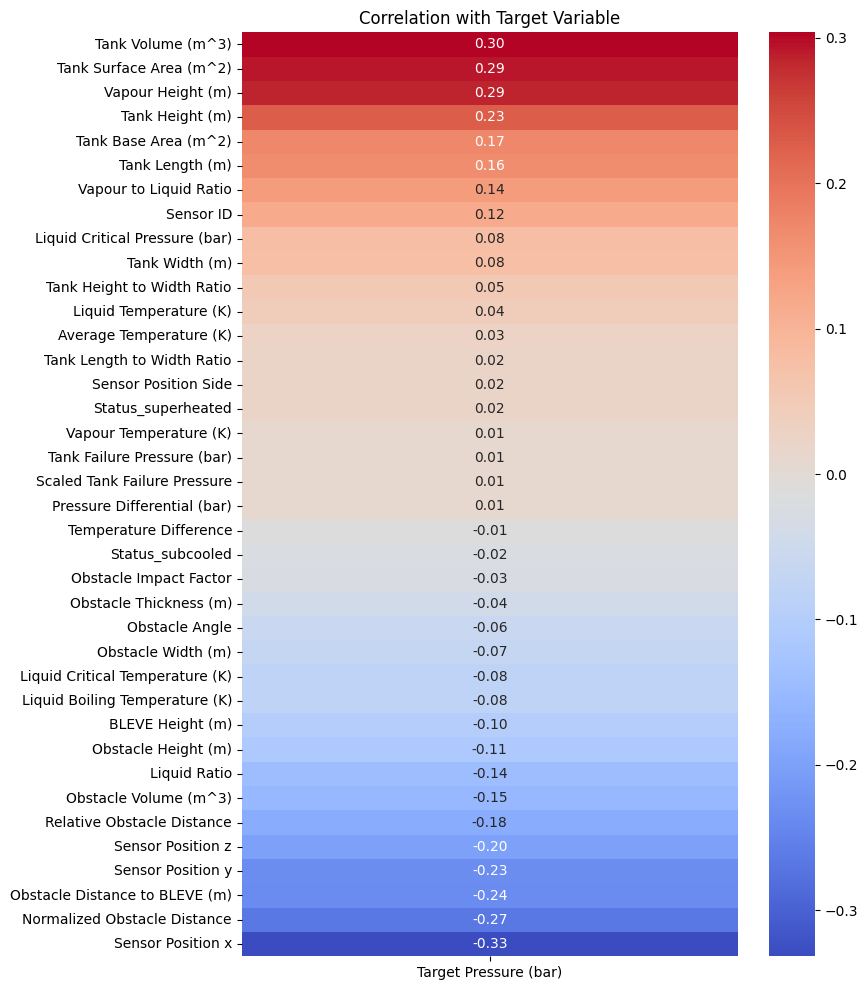

In [98]:
#Finding Correlation between all features

correlation_matrix = train_df.corr()
# Assuming 'Target Pressure (bar)' is the target variable
target_correlation = correlation_matrix['Target Pressure (bar)'].drop('Target Pressure (bar)').sort_values(ascending=False)

#converting the Series to a DataFrame
target_correlation_df = target_correlation.to_frame()

plt.figure(figsize=(8, 12))
sns.heatmap(target_correlation_df, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation with Target Variable')
plt.show()

# 10.Model Preparation


*   Data Splitting for Model Training and Validation
*   Feature Scaling with StandardScaler
*   Lasso Regularization for Feature Selection






In [99]:
from sklearn.model_selection import train_test_split
# Prepare the features and target variable
X = train_df.drop('Target Pressure (bar)', axis=1)
y = train_df['Target Pressure (bar)']

# Split the data into training and testing sets
X_train, X_val, y_train, y_val = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

In [100]:
from sklearn.preprocessing import StandardScaler
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

#Subset test_data to match selected feature names
X_test_raw = test_df[X_train.columns]
#Apply the same scaler used on training data
X_test_scaled = scaler.transform(X_test_raw)

In [101]:
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel
# LassoCV is Lasso with built-in cross-validation to find the best alpha (regularization strength)
lasso = LassoCV(cv=5)

# Select features using LassoCV
selector = SelectFromModel(lasso).fit(X_train, y_train)

# Transform training and test sets
X_train_selected = selector.transform(X_train_scaled)
X_val_selected = selector.transform(X_val_scaled)
X_test_selected = selector.transform(X_test_scaled)


# Get the selected features
selected_features = X_train.columns[selector.get_support()]
print(f'Selected features: {selected_features}')


Selected features: Index(['Tank Failure Pressure (bar)', 'Liquid Ratio', 'Tank Width (m)',
       'Tank Length (m)', 'Tank Height (m)', 'BLEVE Height (m)',
       'Vapour Height (m)', 'Vapour Temperature (K)', 'Liquid Temperature (K)',
       'Obstacle Distance to BLEVE (m)', 'Obstacle Width (m)',
       'Obstacle Height (m)', 'Obstacle Thickness (m)', 'Obstacle Angle',
       'Liquid Boiling Temperature (K)', 'Liquid Critical Temperature (K)',
       'Sensor ID', 'Sensor Position Side', 'Sensor Position x',
       'Sensor Position y', 'Sensor Position z', 'Status_subcooled'],
      dtype='object')


# 11.Model Development
In this development part, i've taken three models, i.e. Random Forest Model, XG Model and Cat Boost model

Firstly,Setting Up for Model Training and Evaluation

In [102]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import time
import warnings
warnings.filterwarnings('ignore')


In [103]:
# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 11.1 Random Forest Model
*   Trains a Random Forest regression model with optimized hyperparameters
*  Uses cross-validation to ensure robust performance evaluation
*   Evaluates model on validation data using multiple metrics







In [34]:

# Define Random Forest model
print("\nTraining Random Forest...")
rf_model = RandomForestRegressor(random_state=42)

# Define hyperparameter grid
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Randomized Search CV
rf_grid_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring={
        'mape': 'neg_mean_absolute_percentage_error',
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error'
    },
    refit='mape',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit model using feature-selected training data

rf_grid_search.fit(X_train_selected, y_train)
best_rf_model = rf_grid_search.best_estimator_

# Predict on validation set
y_val_pred_rf = best_rf_model.predict(X_val_selected)

# Evaluation
mape_rf = mean_absolute_percentage_error(y_val, y_val_pred_rf)
r2_rf = r2_score(y_val, y_val_pred_rf)

# Store results in a list
results = []  # Initialize if not already
results.append((
    "Random Forest",
    mape_rf,
    r2_rf,
    best_rf_model,
    rf_grid_search.best_params_
))

# Print summary
print(f"\nRandom Forest Validation Results:")
print(f"MAPE: {mape_rf:.4f}")
print(f"R² Score: {r2_rf:.4f}")



Training Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Random Forest Validation Results:
MAPE: 0.1841
R² Score: 0.9235


# 11.2 XGBoost Model

*   Gradient Boosting Framework: Builds trees sequentially to correct errors from previous trees
*   Regularization Features: Includes both L1 and L2 regularization to prevent overfitting

*   Advanced Tree Growing: Controls tree complexity through depth, sampling, and column selection
*   Optimization Objective: Uses squared error for regression problems





In [35]:
from xgboost import XGBRegressor

print("\nTraining XGBoost...")

# XGBoost model + pipeline
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_pipeline = Pipeline([('model', xgb_model)])

# Parameter grid
xgb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9],
    'model__reg_alpha': [0, 0.1, 0.5],
    'model__reg_lambda': [0.5, 1, 5]
}

# RandomizedSearchCV
xgb_grid_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring={
        'mape': 'neg_mean_absolute_percentage_error',
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error'
    },
    refit='mape',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_grid_search.fit(X_train_selected, y_train)
best_xgb_model = xgb_grid_search.best_estimator_

# Predict and evaluate
y_val_pred_xgb = best_xgb_model.predict(X_val_selected)

mape_xgb = mean_absolute_percentage_error(y_val, y_val_pred_xgb)  # ← decimal format (e.g., 0.21)
r2_xgb = r2_score(y_val, y_val_pred_xgb)

# Store results
results.append((
    "XGBoost",
    mape_xgb,
    r2_xgb,
    best_xgb_model,
    xgb_grid_search.best_params_
))

print(f"\n XGBoost Validation Results:")
print(f" MAPE: {mape_xgb:.4f}")
print(f"R² Score: {r2_xgb:.4f}")


Training XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 XGBoost Validation Results:
 MAPE: 0.1177
R² Score: 0.9676


I didn't have catboost algorithm so had to install the algorithm.

In [36]:
!pip install catboost

I updated the scikit-learn library to the latest version to ensures access to the most recent features, optimizations, and bug fixes.

In [37]:
!pip install --upgrade scikit-learn

# 11.3 CatBoost Model
*   Installing and Importing Required Libraries
*   CatBoost Model Training with Hyperparameter Optimization
*   Model Fitting and Fine-Tuning
*   Model Evaluation





In [38]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error, mean_absolute_error

print("\nTraining CatBoost...")

# Define CatBoost model with MAPE loss
cat_model = CatBoostRegressor(
    loss_function='MAPE',
    verbose=0,
    random_state=42
)

# Expanded parameter grid for fine-tuning
cat_param_grid = {
    'n_estimators': [500, 1000, 1500],
    'depth': [6, 7, 8, 9],
    'learning_rate': [0.01, 0.02, 0.03, 0.05],
    'l2_leaf_reg': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bylevel': [0.7, 0.8, 0.9],
    'min_data_in_leaf': [1, 3, 5, 7],
    'random_strength': [0.5, 1, 2]
}

# RandomizedSearchCV for hyperparameter tuning
cat_grid_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=cat_param_grid,
    n_iter=60,  # Increase for better tuning
    scoring={
        'mape': 'neg_mean_absolute_percentage_error',
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error'
    },
    refit='mape',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the model to training data
cat_grid_search.fit(X_train_selected, y_train)

# Retrieve the best model
best_cat_model = cat_grid_search.best_estimator_

# Fine-tune best model with early stopping
best_cat_model.fit(
    X_train_selected, y_train,
    eval_set=(X_val_selected, y_val),
    early_stopping_rounds=100,
    verbose=100
)

# Predict on validation set
y_val_pred_cat = best_cat_model.predict(X_val_selected)

# Calculate evaluation metrics
mape_cat = mean_absolute_percentage_error(y_val, y_val_pred_cat)
r2_cat = r2_score(y_val, y_val_pred_cat)
# Calculate RMSE without the 'squared' argument if your scikit-learn version is older
rmse_cat = np.sqrt(mean_squared_error(y_val, y_val_pred_cat))  # Calculate RMSE manually
mae_cat = mean_absolute_error(y_val, y_val_pred_cat)

# Store results
results.append((
    "CatBoost",
    mape_cat,
    r2_cat,
    best_cat_model,
    cat_grid_search.best_params_
))

# Print results
print(f"\nCatBoost Validation Results:")
print(f"MAPE: {mape_cat:.4f}")
print(f" R² : {r2_cat:.4f}")
print(f"RMSE: {rmse_cat:.4f}")
print(f" MAE: {mae_cat:.4f}")
print(f"Best Params: {cat_grid_search.best_params_}")



Training CatBoost...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
0:	learn: 0.1592817	test: 0.1634233	best: 0.1634233 (0)	total: 14.8ms	remaining: 22.2s
100:	learn: 0.0552241	test: 0.0597620	best: 0.0597620 (100)	total: 1.42s	remaining: 19.6s
200:	learn: 0.0379696	test: 0.0438087	best: 0.0438087 (200)	total: 2.78s	remaining: 18s
300:	learn: 0.0313398	test: 0.0383351	best: 0.0383351 (300)	total: 4.14s	remaining: 16.5s
400:	learn: 0.0276288	test: 0.0353677	best: 0.0353677 (400)	total: 5.55s	remaining: 15.2s
500:	learn: 0.0248445	test: 0.0332161	best: 0.0332161 (500)	total: 6.91s	remaining: 13.8s
600:	learn: 0.0227035	test: 0.0315955	best: 0.0315955 (600)	total: 8.27s	remaining: 12.4s
700:	learn: 0.0210789	test: 0.0304034	best: 0.0304034 (700)	total: 10.3s	remaining: 11.7s
800:	learn: 0.0199562	test: 0.0295912	best: 0.0295912 (800)	total: 12.6s	remaining: 11s
900:	learn: 0.0188560	test: 0.0288681	best: 0.0288681 (900)	total: 14s	remaining: 9.3s
1000:	learn: 0.0179466	tes

Since after looking into all three models, the MAPE of CatBoost Model is the best for further predictions.

In [39]:
#Predict using the best CatBoost model
y_pred_test = best_cat_model.predict(X_test_selected)

# Add predictions to test_data
test_df['Target Pressure (bar)'] = y_pred_test

submission = pd.DataFrame({
    "ID":range(len(X_test_selected)),  # Use range to create a sequence of numbers
    "Target Pressure (bar)": y_pred_test
})
submission.to_csv("prediction.csv", index=False)
print("\nTest predictions saved to 'prediction.csv'")


Test predictions saved to 'prediction.csv'


# 12.Model Interpretation

According to the evaluation of MAPE, Catboost model has been the best model for further interpretation.

In [40]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Use selected, scaled training features
explainer = shap.TreeExplainer(best_cat_model)
shap_values = explainer.shap_values(X_train_selected)



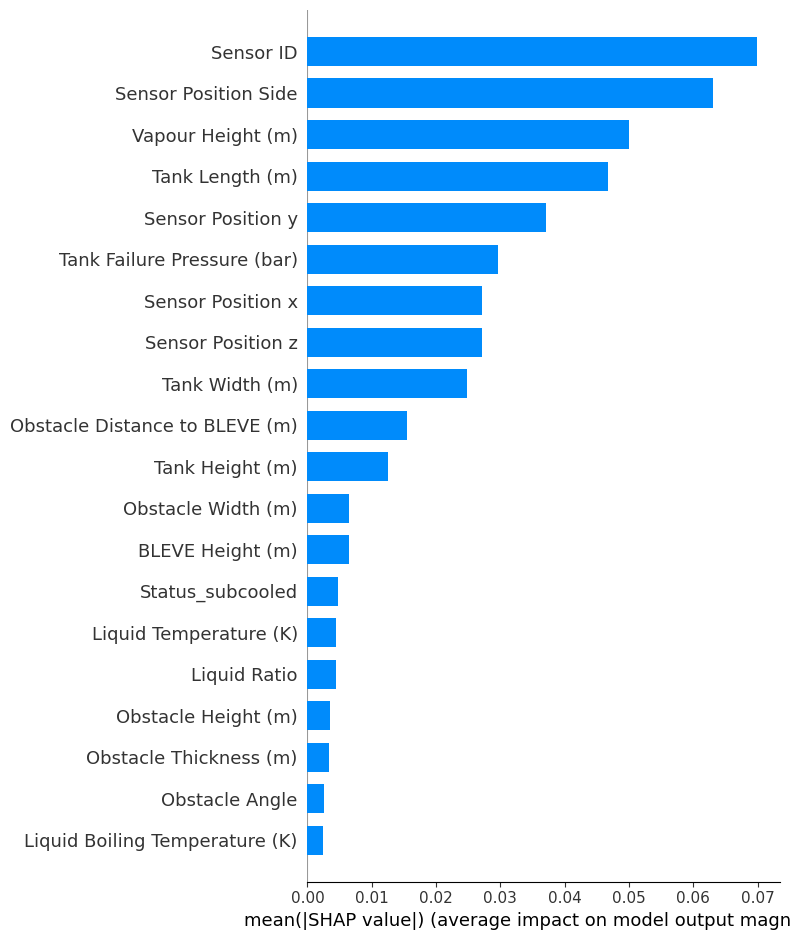

In [104]:
#Feature Importance Plot (Bar)
shap.summary_plot(shap_values, X_train_selected, plot_type="bar", feature_names=selected_features)



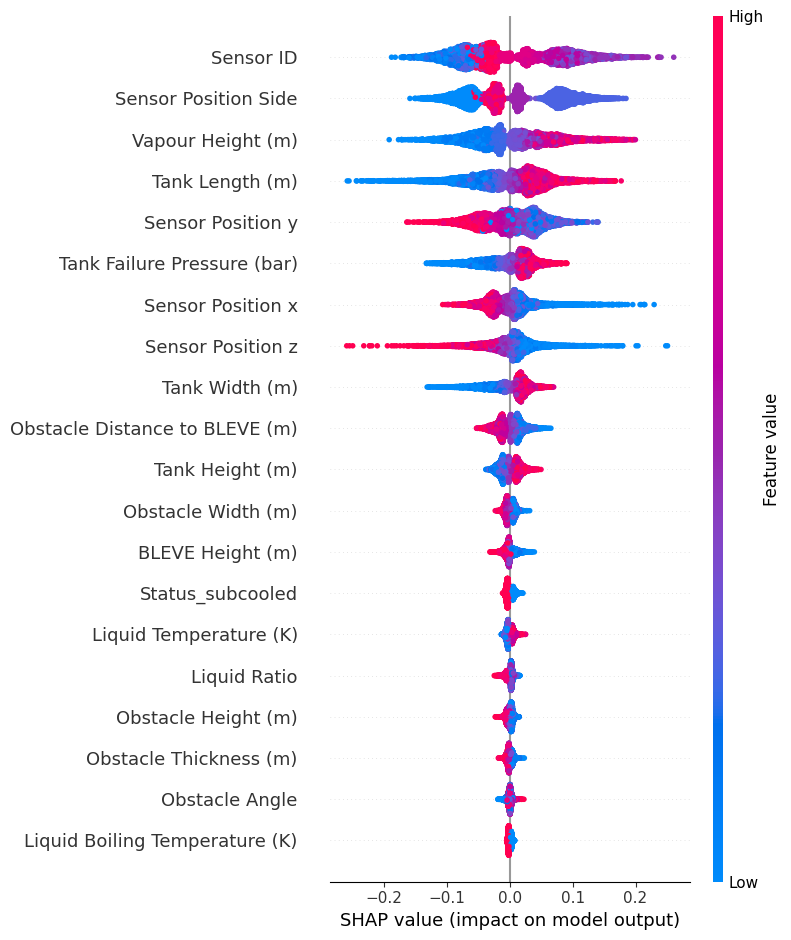

In [105]:
#Feature Effect Plot (Summary Plot)
shap.summary_plot(shap_values, X_train_selected, feature_names=selected_features)


This visualization displays how different features impact a machine learning model's predictions for BLEVE (Boiling Liquid Expanding Vapor Explosion) risk.
**Key Insights:**

*   Sensor positioning (x, y, z, side) shows varied distribution patterns, with position z exhibiting the widest range and distinctive clustering
*   Tank dimensions and obstacle distance are moderately important factors
*  Liquid properties (temperature, ratio, boiling point) show lesser but still meaningful impacts
*   Red points indicate higher feature values, blue indicates lower values
*   Horizontal position shows positive (right) or negative (left) impact on model output

The plot effectively identifies the most critical monitoring parameters for BLEVE risk assessment, with sensor placement emerging as the dominant factor, followed by physical tank characteristics and environmental conditions.

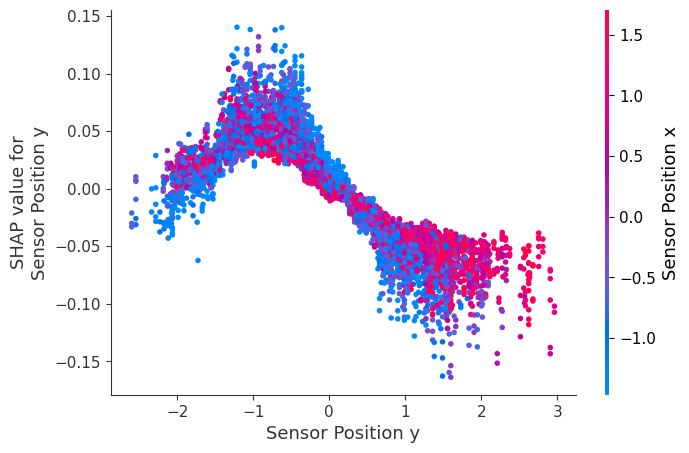

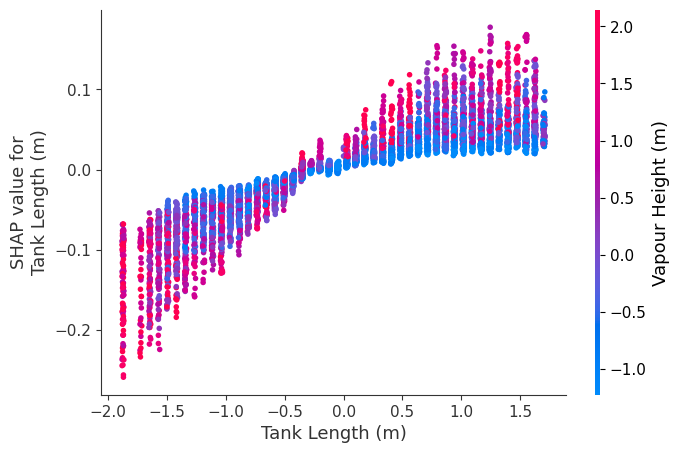

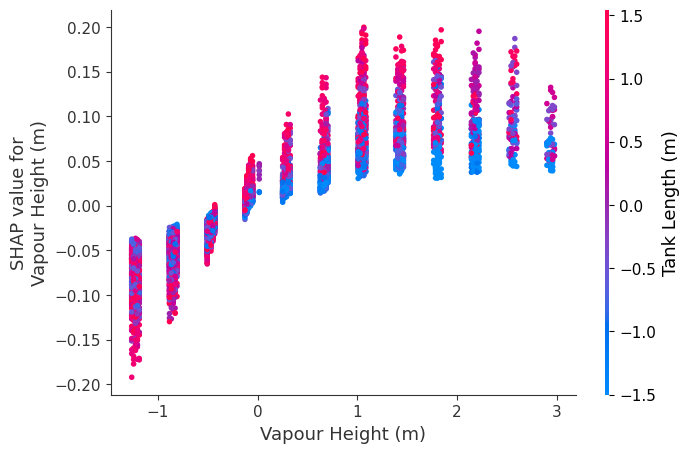

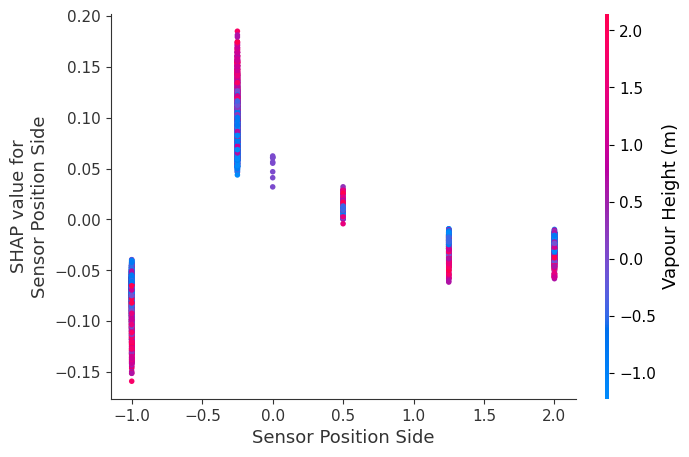

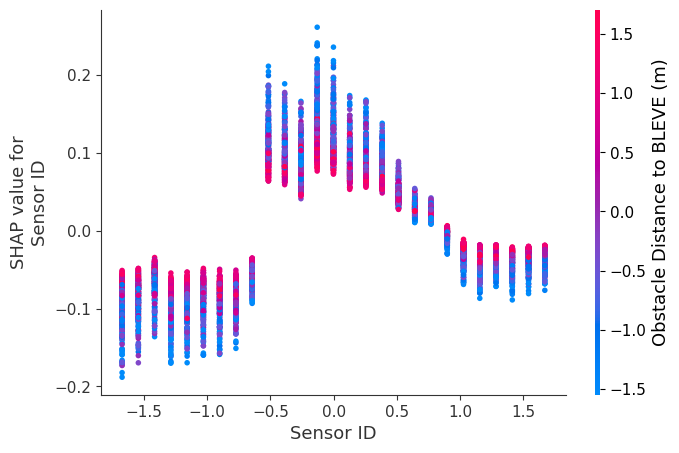

In [106]:
#Partial Dependence Plots for Top 5 Features
top_indices = np.argsort(np.abs(shap_values).mean(0))[-5:]
for idx in top_indices:
    shap.dependence_plot(idx, shap_values, X_train_selected, feature_names=selected_features)


**Plot 1 explanation**


The graph illustrates how Sensor Position y affects the model's predictions while interacting with Sensor Position x.


**Key Insights:**

*   Peak impact occurs at y values between -1 and 0, with positive SHAP values (0.05-0.15)
*   Declining impact as y increases beyond 0, becoming increasingly negative
*   Clear interaction with Sensor Position x (shown by color: red=higher, blue=lower)
*   Position clustering shows lower x values (blue) dominate at negative y, while higher x values (red) appear more at positive y

The non-linear relationship reveals optimal sensor placement zones, with y positions between -1 and 0 having the strongest positive influence on model predictions, suggesting this might be the ideal range for effective BLEVE risk monitoring.


**Plot 2 Explanation:**


The graph shows how Tank Length affects model predictions for BLEVE risk while interacting with Vapour Height.


**Key Insights:**


*   Strong positive correlation: As Tank Length increases from negative to positive values, its impact on the model output shifts from strongly negative (-0.2) to positive (0.1)

*   Transition point: Around Tank Length = 0, the impact changes from negative to positive
*   Feature interaction: Colors indicate Vapour Height values (red = higher, blue = lower), showing that higher Vapour Height (redder points) generally amplifies the effect of Tank Length
*   Critical regions: The most negative impacts occur with shorter tanks (< -1.5m) combined with higher vapour heights (red points)


This visualization reveals that longer tanks tend to increase predicted risk, especially when combined with higher vapour heights, while shorter tanks generally decrease risk predictions in the BLEVE monitoring system.



**Plot3 Explanation**

This graph shows how Vapour Height affects model predictions for BLEVE risk while interacting with Tank Length.

**Key Insights:**

- **Stepped positive relationship**: As Vapour Height increases from negative to positive values, its impact on model predictions rises in a clear stepped pattern
  
- **Transition point**: Around Vapour Height = 0, the impact shifts from negative to positive

- **Plateau effect**: The positive impact peaks around Vapour Height = 1m (+0.20) and then slightly decreases for values beyond 2m

- **Minimal interaction effect**: The color distribution (representing Tank Length) shows similar patterns across different Vapour Height values, suggesting the effect is largely independent of Tank Length

- **Discrete clusters**: The vertical banding pattern indicates that Vapour Height was likely measured or binned at specific intervals rather than as a continuous variable

This visualization reveals that higher vapour heights strongly increase predicted BLEVE risk, with the most significant positive impact occurring between 0.5m and 2m.

**Plot 4 Explanation:**

SHAP Partial Dependence Plot: Sensor Position Side

This graph shows how Sensor Position Side affects model predictions for BLEVE risk while interacting with Vapour Height.

**Key Insights:**

- **Categorical pattern**: Sensor Position Side appears to be a discrete variable with specific values (-1.0, -0.25, 0.25, 1.25, 2.0)

- **Strong position effect**: Position -0.25 has the highest positive impact (+0.15 to +0.18), while Position -1.0 has the strongest negative impact (-0.15)

- **Clear hierarchy**: The impact decreases in order: -0.25 (highest) > 0.0 > 0.5 > 1.25 ≈ 2.0 (lowest)

- **Minimal interaction**: The color distribution (representing Vapour Height) shows similar patterns across positions, suggesting the effect is largely independent of Vapour Height

This visualization reveals that sensor side positioning significantly affects model predictions, with the -0.25 position having the strongest positive influence on BLEVE risk assessment, suggesting this may be an optimal or critical monitoring position.

**Plot 5 Explanation**

SHAP Partial Dependence Plot: Sensor ID

This graph shows how Sensor ID affects model predictions for BLEVE risk while interacting with Obstacle Distance to BLEVE.

**Key Insights:**

- **Three distinct regions**:
  - Negative IDs (-1.5 to -0.8): Negative impact (-0.05 to -0.2)
  - Slightly negative to positive IDs (-0.5 to 0.5): Strong positive impact (0.05 to 0.25)
  - Higher positive IDs (0.7 to 1.5): Slight negative impact (-0.05 to -0.1)

- **Vertical clustering**: Each ID value shows as a vertical band, indicating discrete sensor identifiers rather than continuous values

- **Peak performance**: Sensors with IDs around -0.25 and 0.0 have the strongest positive impact on predictions

- **Minimal interaction**: The color distribution (representing Obstacle Distance) shows similar patterns within each vertical band, suggesting limited interaction between these variables

This visualization reveals that specific sensor IDs (particularly those between -0.5 and 0.5) significantly enhance model predictions, suggesting these sensors may have optimal positioning or superior detection capabilities for BLEVE risk monitoring.

In [46]:
print(selected_features)


Index(['Tank Failure Pressure (bar)', 'Liquid Ratio', 'Tank Width (m)',
       'Tank Length (m)', 'Tank Height (m)', 'BLEVE Height (m)',
       'Vapour Height (m)', 'Vapour Temperature (K)', 'Liquid Temperature (K)',
       'Obstacle Distance to BLEVE (m)', 'Obstacle Width (m)',
       'Obstacle Height (m)', 'Obstacle Thickness (m)', 'Obstacle Angle',
       'Liquid Boiling Temperature (K)', 'Liquid Critical Temperature (K)',
       'Sensor ID', 'Sensor Position Side', 'Sensor Position x',
       'Sensor Position y', 'Sensor Position z', 'Status_subcooled'],
      dtype='object')


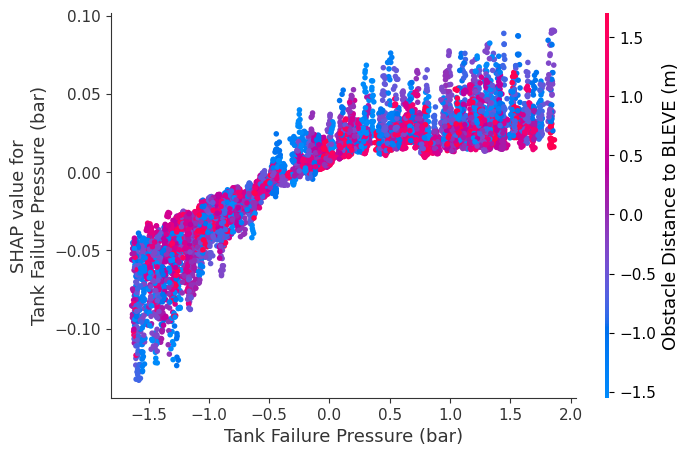

In [107]:
#Feature Interaction Plots
shap.dependence_plot(
    "Tank Failure Pressure (bar)",
    shap_values,
    X_train_selected,
    feature_names=selected_features,
    interaction_index="Obstacle Distance to BLEVE (m)"
)


**Dependence Plot: Tank Failure Pressure(bar)**

This graph shows how Tank Failure Pressure affects model predictions while interacting with Obstacle Distance to BLEVE.

**Key Insights:**

- **Strong positive correlation**: As Tank Failure Pressure increases from negative to positive values, its impact shifts from strongly negative (-0.12) to moderately positive (0.05)

- **Non-linear relationship**: The curve shows a sigmoid-like pattern with steepest increase between -0.5 and 0.5 bar, then plateauing beyond 0.5 bar

- **Transition point**: Around 0 bar, the impact changes from negative to positive

- **Minimal feature interaction**: The color distribution (representing Obstacle Distance to BLEVE) shows relatively uniform mixing across the pressure range, suggesting limited interaction between these variables

This visualization reveals that higher tank failure pressure values positively impact model predictions, with the strongest positive influence occurring between 0.5-2.0 bar, likely indicating increased BLEVE risk at higher pressure thresholds.

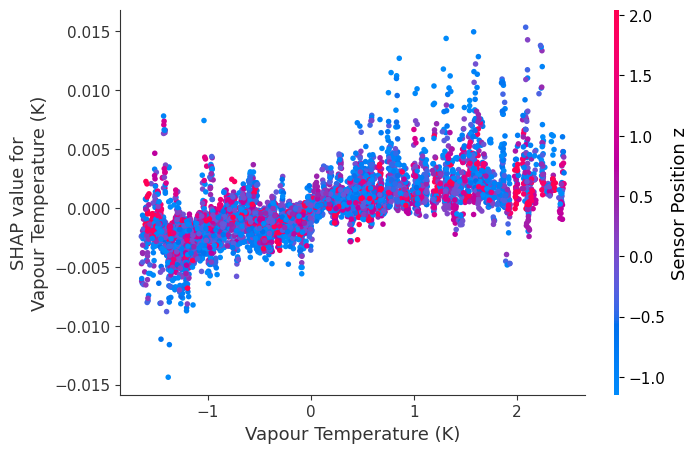

In [49]:
shap.dependence_plot(
    "Vapour Temperature (K)",
    shap_values,
    X_train_selected,
    feature_names=selected_features,
    interaction_index="Sensor Position z"
)


**Dependence Plot: Vapour Temperature**

This graph shows how Vapour Temperature affects model predictions while interacting with Sensor Position z.

**Key Insights**:

- **Subtle positive relationship**: As Vapour Temperature increases (especially beyond 0K), its impact generally shifts from slightly negative (-0.005) to moderately positive (0.005-0.015)

- **Small magnitude effect**: The overall SHAP values range is narrow (-0.015 to 0.015), indicating this feature has a relatively minor impact compared to other variables examined

- **Transitional threshold**: Around 0K, there's a noticeable shift in behavior, with more variability and higher positive impacts appearing for temperatures above this point

- **Scattered pattern**: The dispersed points indicate considerable variability in impact at similar temperature values, suggesting interactions with other features

- **Limited interaction with Sensor Position z**: The color distribution (blue to red) shows some clustering but no strong pattern, indicating modest interaction between these variables

This visualization reveals that while Vapour Temperature has a smaller overall impact than other features, higher temperatures tend to positively influence model predictions, particularly around 1-2K, where some of the highest positive SHAP values occur.

In [54]:


# Use JavaScript-based visualization (interactive, better layout)
shap.initjs()

# Recompute local predictions
y_pred_train = best_cat_model.predict(X_train_selected)
errors = np.abs((y_train - y_pred_train) / y_train)

lowest_idx = np.argmin(y_pred_train)
highest_idx = np.argmax(y_pred_train)
largest_err_idx = np.argmax(errors)

# Display each SHAP force plot cleanly
for idx, label in zip([lowest_idx, highest_idx, largest_err_idx], ["Lowest", "Highest", "Largest Error"]):
    print(f"\n{label} Prediction (index: {idx})")
    display(
        shap.force_plot(
            explainer.expected_value,
            shap_values[idx],
            X_train_selected[idx],
            feature_names=selected_features,
            matplotlib=False  # Use JavaScript rendering
        )
    )



Lowest Prediction (index: 840)



Highest Prediction (index: 5248)



Largest Error Prediction (index: 6437)


**Individual Prediction Explanations**

This visualization shows SHAP force plots for three specific predictions from the BLEVE risk model, explaining how different features push the prediction value higher (red) or lower (blue) from the base value.

Three Key Scenarios:

1. Lowest Prediction (index: 840) - Output: 0.02
- **Base value:** ~0.264
- **Key factors reducing prediction:**
  - Negative Tank Failure Pressure (-1.364 bar)
  - Small Tank Height (-1.433 m)
  - Negative Tank Width (-0.9411 m)
  - Low Vapour Height (-0.828 m)
- **Positive contributors:**
  - Sensor Position y (1.273)
- Overall, tank dimensions and pressure are driving this low-risk prediction.

2. Highest Prediction (index: 5248) - Output: 1.85
- **Base value:** ~0.264  
- **Key factors increasing prediction:**
  - Large Tank Length (1.245 m)
  - High Vapour Height (0.6495 m)
  - Optimal Sensor Position Side (-0.2521)
  - Sensor Position x (-1.659)
  - Sensor Position z (-1.148)
- Every feature contributes positively (red arrows), creating a strong consensus for high risk.

3. Largest Error Prediction (index: 6437) - Output: 0.51
- **Base value:** ~0.264
- **Mixed influences:**
  - Most features push prediction higher (red)
  - Sensor Position x (0.228) is the main factor pulling prediction lower (blue)
- This case shows disagreement between features, explaining why the model had its largest error.

These force plots provide valuable insight into how the model makes decisions for specific examples, revealing which combinations of features create low-risk vs. high-risk predictions in the BLEVE monitoring system.